<a href="https://colab.research.google.com/github/ChanggonSong/AI-Study/blob/main/wine_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

회귀 문제: residual sugar를 예측

In [335]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [336]:
rWine = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/winequality-red.csv',  sep=';')
wWine = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/winequality-white.csv',  sep=';')

In [337]:
rWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [338]:
wWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [339]:
# 결측치 개수 파악
rWine.isnull().sum().to_frame('nan_count')
# 결측치 비율 파악
pd.DataFrame(data=rWine.isnull().sum()/len(rWine),columns=['nan_ratio'])

,nan_ratio
fixed acidity,0.0
volatile acidity,0.0
citric acid,0.0
residual sugar,0.0
chlorides,0.0
free sulfur dioxide,0.0
total sulfur dioxide,0.0
density,0.0
pH,0.0
sulphates,0.0


In [340]:
# 결측치 개수 파악
wWine.isnull().sum().to_frame('nan_count')
# 결측치 비율 파악
pd.DataFrame(data=wWine.isnull().sum()/len(wWine),columns=['nan_ratio'])

,nan_ratio
fixed acidity,0.0
volatile acidity,0.0
citric acid,0.0
residual sugar,0.0
chlorides,0.0
free sulfur dioxide,0.0
total sulfur dioxide,0.0
density,0.0
pH,0.0
sulphates,0.0


fixed acidity : 고정 산도
volatile acidity : 휘발성 산도
citric acid : 시트르산
residual sugar : 잔류 당분
chlorides : 염화물
free sulfur dioxide : 자유 이산화황
total sulfur dioxide : 총 이산화황
density : 밀도
pH
sulphates : 황산염
alcohol
quality : 0 ~ 10(높을 수록 좋은 품질)

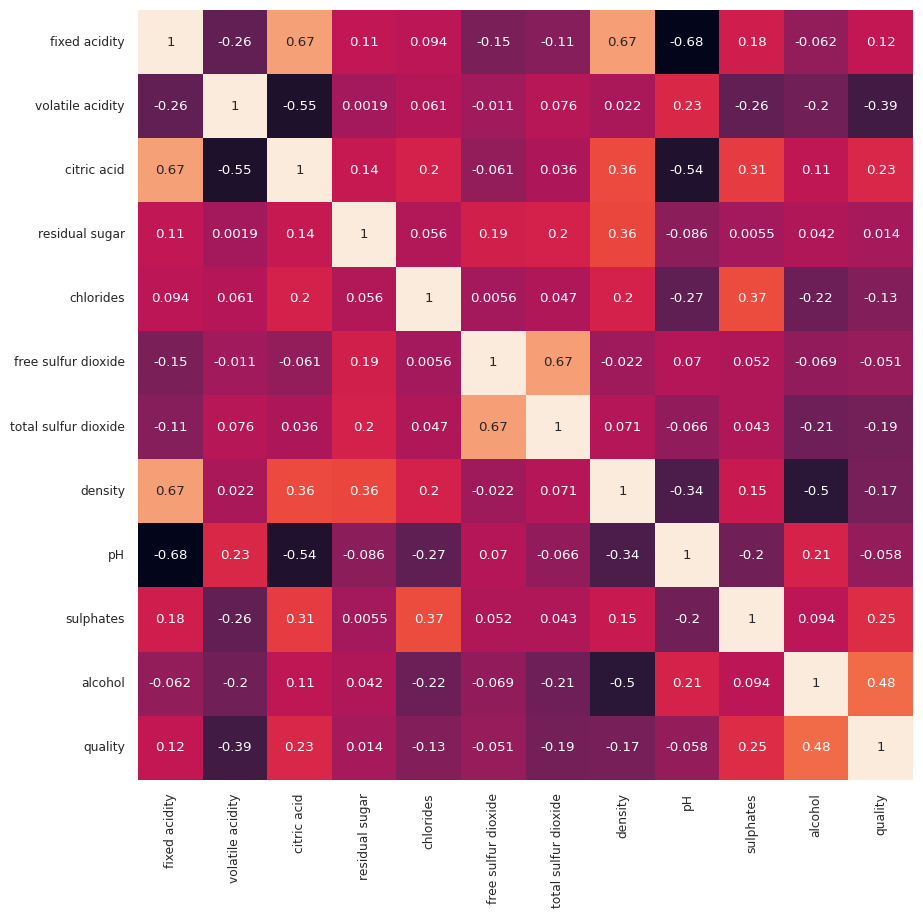

In [341]:
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음
data_corr=rWine.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(data_corr, annot=True, cbar=False)
plt.show()

# residual sugar와 가장 상관성 강한 건 density

####Set x and y values

In [987]:
y = rWine['residual sugar']
y.head()

0    1.9
1    2.6
2    2.3
3    1.9
4    1.9
Name: residual sugar, dtype: float64

In [1015]:
# 상관관계 낮은 것 제거
columns_to_drop = ['residual sugar', 'volatile acidity', 'sulphates']
X = rWine.drop(columns=columns_to_drop, axis=1)

In [1041]:
# train/test 8:2비율로 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1279, 9) (1279,)
(320, 9) (320,)


In [1066]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ly_preds = model.predict(X_test)
mse = np.sqrt(mean_squared_error(ly_preds, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.0680193621677692


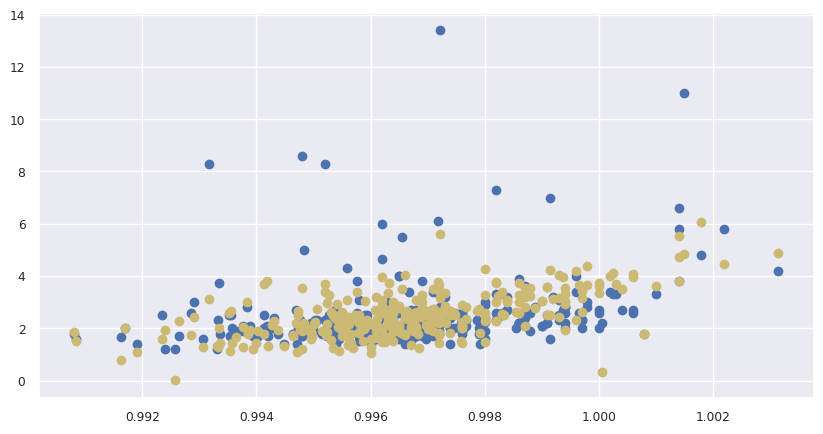

In [1120]:
# 예측값과 실제 값 차이를 산접도로 표시, 노란색 예측

plt.figure(figsize=(10,5))
plt.scatter(X_test['density'], y_test, label='y_test')
plt.scatter(X_test['density'], ly_preds, c='y', label='ly_preds')
#plt.plot(X_train, lr.predict(X_train), color='blue')
plt.show()

In [1148]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test)
mse = np.sqrt(mean_squared_error(dy_preds, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.165208538202497


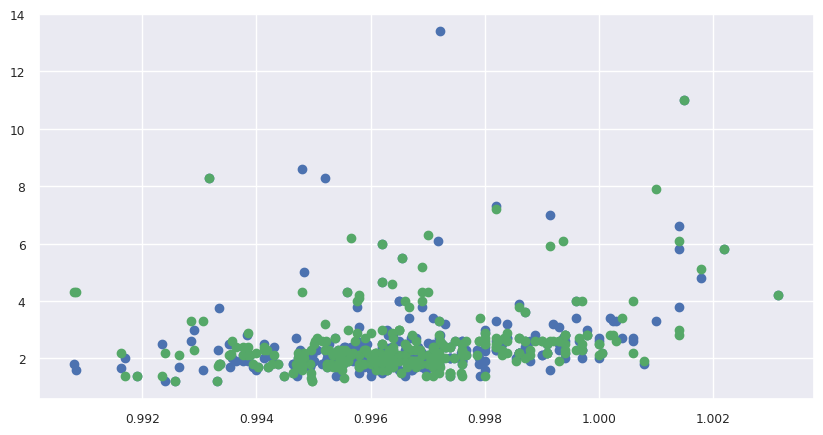

In [1149]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['density'], y_test, label='y_test')
plt.scatter(X_test['density'], dy_preds, c='g', label='dy_preds')
plt.show()

In [1175]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test)
mse = np.sqrt(mean_squared_error(ry_preds, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 0.9377643568948971


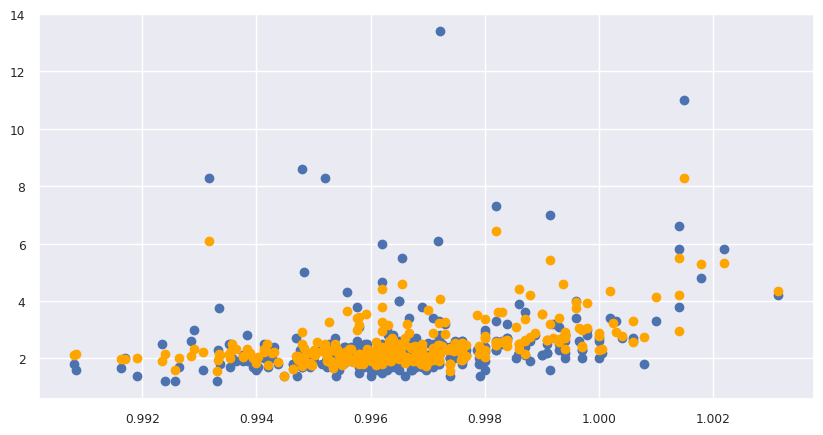

In [1200]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['density'], y_test, label='y_test')
plt.scatter(X_test['density'], ry_preds, c='orange', label='ry_preds')

plt.show()

In [1224]:
from sklearn.svm import SVR

model = SVR(kernel='linear')
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test)
mse = np.sqrt(mean_squared_error(ry_preds, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.2844040410609736


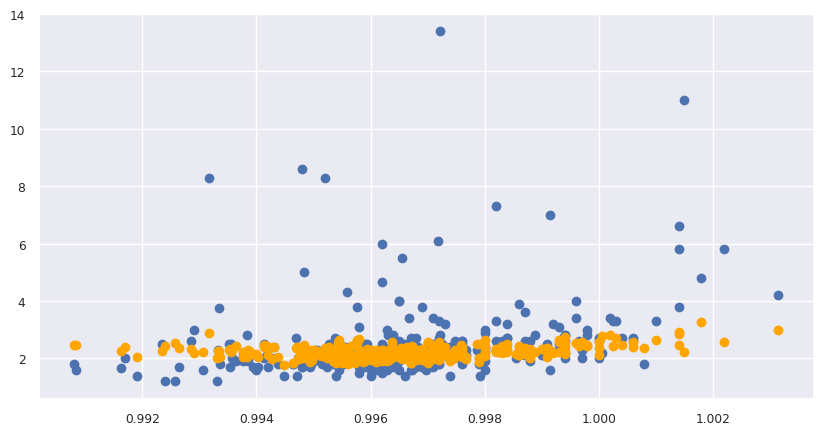

In [1226]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['density'], y_test, label='y_test')
plt.scatter(X_test['density'], ry_preds, c='orange', label='ry_preds')

plt.show()

In [1250]:
# 다시 train set을 8:2로 나눠서 validation set까지 만들기
X_sub, X_valid, y_sub, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(X_sub.shape, X_valid.shape)

(1023, 9) (256, 9)


In [1251]:
from sklearn.tree import DecisionTreeRegressor

clf_dt = DecisionTreeRegressor()
clf_dt.fit(X_sub, y_sub)


print(clf_dt.score(X_sub, y_sub))
print(clf_dt.score(X_valid, y_valid))

1.0
0.31242342555621305


In [1252]:
# 교차 검증 진행
from sklearn.model_selection import cross_validate
scores = cross_validate(clf_dt, X_train, y_train)
print(scores)

{'fit_time': array([0.01816583, 0.01439691, 0.01347017, 0.01275015, 0.0466733 ]), 'score_time': array([0.00276208, 0.00265431, 0.00270629, 0.00249052, 0.00304914]), 'test_score': array([ 0.29151562,  0.5776187 , -0.09267885,  0.42291672,  0.34882053])}


In [1253]:
print(np.mean(scores['test_score']))

0.3096385447884059


In [1254]:
from sklearn.model_selection import KFold
scores = cross_validate(clf_dt, X_train, y_train, cv=KFold(), scoring='neg_mean_squared_error')
print(np.mean(scores['test_score']))

-1.3091051011029413


In [1255]:
splitter = KFold(n_splits=10,shuffle=True, random_state=42)
scores = cross_validate(clf_dt, X_train, y_train, cv=splitter)
print(np.mean(scores['test_score']))

0.2501748649619365


In [1256]:
#각 셀의 데이터 개수 출력하기
print('모든 데이터', X.shape)
print('train set', X_train.shape, y_train.shape)
print('valid set', X_valid.shape, y_valid.shape)
print('test set', X_test.shape, y_test.shape)

모든 데이터 (1599, 9)
train set (1279, 9) (1279,)
valid set (256, 9) (256,)
test set (320, 9) (320,)


In [1257]:
# PolynomialFeature을 적용
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=1,include_bias=False)
poly.fit(X_sub)
train_poly = poly.transform(X_sub)
print(train_poly.shape)

(1023, 9)


In [1258]:
test_poly = poly.transform(X_test)

In [1259]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, y_sub)
print(lr.score(train_poly, y_sub))
print(lr.score(test_poly, y_test))

0.3934963600098992
0.3276004805249473


####규제 regularization 진행

- 먼저 정규화 진행

In [1260]:
# StandardScaler 변환기(transformer)
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

- 릿지 회귀 사용

In [1274]:
# ridge
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(train_scaled, y_sub)
print(ridge.score(train_scaled, y_sub))
print(ridge.score(test_scaled, y_test))

0.393474323872668
0.32772783184578314


In [1275]:
# alpha값 찾기
train_score = []
test_score = []

alpha_list = [0.001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
for alpha in alpha_list:
  ridge = Ridge(alpha=alpha)
  ridge.fit(train_scaled, y_sub)
  train_score.append(ridge.score(train_scaled, y_sub))
  test_score.append(ridge.score(test_scaled, y_test))

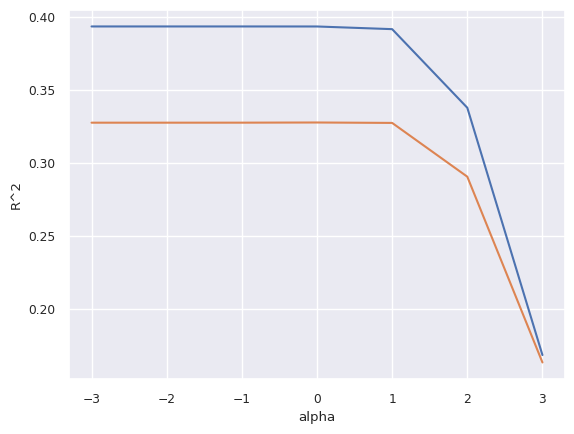

In [1276]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

alpha값: 10^2=100

In [1277]:
ridge = Ridge(alpha=100)
ridge.fit(train_scaled, y_sub)
print(ridge.score(train_scaled, y_sub))
print(ridge.score(test_scaled, y_test))

0.3378134076247037
0.29061833347436006


In [1278]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix

In [1279]:
from sklearn.tree import DecisionTreeRegressor

clf_dt = DecisionTreeRegressor()
clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print(clf_dt.score(X_train, y_train))

1.0


In [1280]:
mse = np.sqrt(mean_squared_error(pred_dt, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.099179381402326


In [1281]:
from sklearn.ensemble import RandomForestRegressor

rf_clf = RandomForestRegressor()
rf_clf.fit(X_train, y_train)

pred_rf = rf_clf.predict(X_test)

print(rf_clf.score(X_train, y_train))

0.9398408352161588


In [1282]:
mse = np.sqrt(mean_squared_error(pred_rf, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 0.9494819220567078


In [1283]:
from sklearn.linear_model import LinearRegression

clf_lr = LinearRegression()
clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print(clf_lr.score(X_train, y_train))

0.39780983439991524


In [1284]:
mse = np.sqrt(mean_squared_error(pred_lr, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.0680193621677692


In [1285]:
from sklearn.svm import SVR

clf_svm = SVR()
clf_svm.fit(X_train, y_train)

pred_svm = clf_svm.predict(X_test)

print(clf_svm.score(X_train, y_train))

0.027238924691368016


In [1286]:
mse = np.sqrt(mean_squared_error(pred_svm, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.2573306191599198
